# Exploratory Data Analysis — Vendor Performance Dataset

**Project:** Supply Chain Analytics — Vendor Performance & Risk Dashboard
**Author:** Rishabh Sharma
**Date:** May 13, 2026

## Objective
Profile the synthetic vendor dataset to understand its structure, identify data quality issues, and document findings before cleaning.

## Dataset
`data/raw/vendors.csv` — 5,000 rows of synthetic vendor transaction data covering 10 Indian auto-component suppliers across 4 regions.

## What This Notebook Covers
1. Load the dataset and inspect basic structure
2. Examine data types and column descriptions
3. Profile missing values
4. Profile categorical columns (vendor names, regions, delivery status)
5. Profile numeric columns (defect rates, order values, delivery days)
6. Identify outliers
7. Document findings and cleaning plan

In [2]:
# Standard data analysis imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings — show more rows/columns when inspecting data
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load the raw vendor dataset
df = pd.read_csv("../data/raw/vendors.csv")

# Confirm load with shape and first few rows
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 5,000 rows × 10 columns


,vendor_id,vendor_name,region,order_date,promised_days,actual_days,defect_rate,order_value,payment_days,delivery_status
0,V007,Sandhar Technologies,East,2024-07-15,12,13,6.505000,295468.141238,85.0,Slight Delay
1,V004,Minda Industries,South,2023-10-29,8,13,4.987171,456968.003250,59.0,Major Delay
2,V008,Lumax Industries,East,2033-04-25,6,7,11.959936,87045.015409,79.0,Slight Delay
3,V005,Uno Minda,North,2034-09-20,9,13,0.612421,167440.726494,61.0,Major Delay
4,V007,Uno Minda,South,2024-05-24,5,3,8.888983,225188.187928,86.0,on-Time


In [4]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   vendor_id        5000 non-null   str    
 1   vendor_name      5000 non-null   str    
 2   region           4950 non-null   str    
 3   order_date       5000 non-null   str    
 4   promised_days    5000 non-null   int64  
 5   actual_days      5000 non-null   int64  
 6   defect_rate      4850 non-null   float64
 7   order_value      5000 non-null   float64
 8   payment_days     4900 non-null   float64
 9   delivery_status  5000 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 390.8 KB


In [5]:
# Statistical summary of numeric columns
df.describe()


,promised_days,actual_days,defect_rate,order_value,payment_days
count,5000.000000,5000.000000,4850.000000,5.000000e+03,4900.000000
mean,9.474800,12.696200,5.581722,2.777358e+05,60.267551
std,2.883302,4.323337,3.397898,2.946703e+05,17.654842
min,5.000000,3.000000,0.000308,1.007143e+04,30.000000
25%,7.000000,10.000000,2.752793,1.375044e+05,45.000000
50%,10.000000,13.000000,5.516771,2.599070e+05,60.000000
75%,12.000000,16.000000,8.161362,3.819056e+05,75.000000
max,14.000000,26.000000,14.997332,4.931182e+06,90.000000


In [6]:
# Profile categorical (string) columns
df.describe(include="object")

/tmp/ipykernel_4451/3223979394.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,vendor_id,vendor_name,region,order_date,delivery_status
count,5000,5000,4950,5000,5000
unique,10,20,8,3171,3
top,V001,Lumax Industries,West,2034-06-06,Major Delay
freq,533,511,1251,6,2336


In [7]:
# Count missing values per column
missing_counts = df.isna().sum()

# Calculate percentage
missing_pct = (df.isna().sum() / len(df)) * 100

# Combine into a single DataFrame for readability
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(2)
})

# Show only columns with missing values, sorted by count
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
defect_rate,150,3.0
payment_days,100,2.0
region,50,1.0


In [8]:
# Show every distinct value in vendor_name with its frequency
df["vendor_name"].value_counts()

vendor_name
Lumax Industries         511
Varroc Engineering       510
Bharat Forge             496
Spark Minda              487
Endurance Tech           483
Motherson Sumi           479
Sandhar Technologies     463
Minda Industries         460
Uno Minda                435
Samvardhana Motherson    426
MOTHERSON SUMI            36
LUMAX INDUSTRIES          27
VARROC ENGINEERING        27
ENDURANCE TECH            25
SAMVARDHANA MOTHERSON     25
BHARAT FORGE              24
MINDA INDUSTRIES          23
SANDHAR TECHNOLOGIES      22
SPARK MINDA               21
UNO MINDA                 20
Name: count, dtype: int64

In [9]:
# Same casing check for region
df["region"].value_counts()

region
West     1251
North    1203
South    1192
East     1156
west       43
east       40
south      34
north      31
Name: count, dtype: int64

In [10]:
df["region"].value_counts(dropna=False)

region
West     1251
North    1203
South    1192
East     1156
NaN        50
west       43
east       40
south      34
north      31
Name: count, dtype: int64

In [11]:
#Convert order date to date time
df["order_date"] = pd.to_datetime(df["order_date"])

#Inspect the date range
print(f"Earliest order: {df['order_date'].min()}")
print(f"Latest order: {df['order_date'].max()}")
print(f"Date span: {df['order_date'].max() - df['order_date'].min()}")
print(f"\nDistribution by year:")
df['order_date'].dt.year.value_counts().sort_index()

Earliest order: 2023-01-01 00:00:00
Latest order: 2036-09-08 00:00:00
Date span: 4999 days 00:00:00

Distribution by year:


order_date
2023    353
2024    378
2025    358
2026    396
2027    392
2028    393
2029    344
2030    369
2031    375
2032    343
2033    342
2034    366
2035    311
2036    280
Name: count, dtype: int64

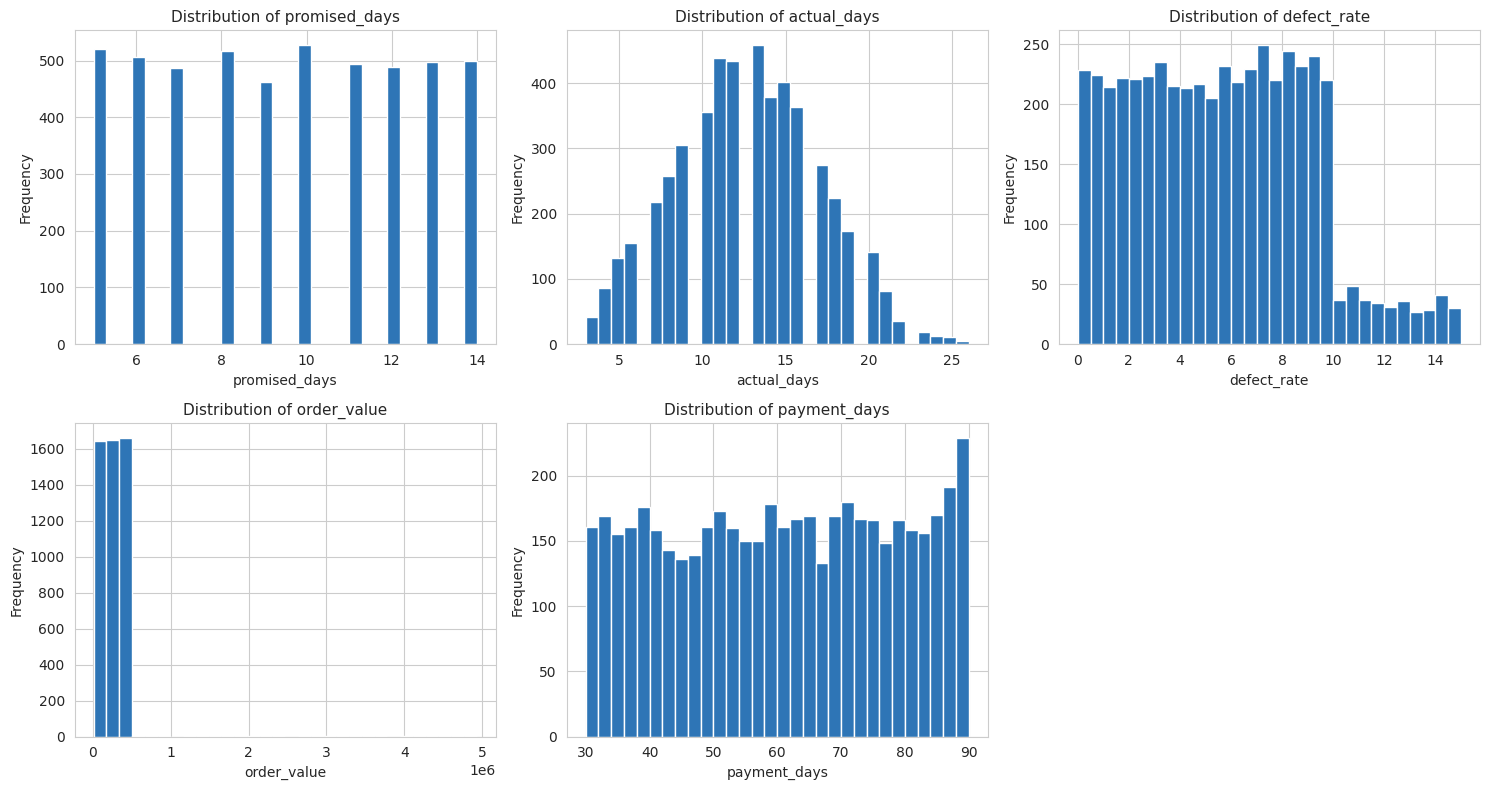

In [12]:
# Visualize numeric distributions with histograms
numeric_cols = ["promised_days", "actual_days", "defect_rate", "order_value", "payment_days"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[i], bins=30, color="#2E75B6", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

## EDA Findings & Cleaning Plan

### Data Quality Issues Identified

| # | Issue | Column(s) | Severity | Resolution Strategy |
|---|-------|-----------|----------|---------------------|
| 1 | Missing values | `region` (1%), `defect_rate` (3%), `payment_days` (2%) | Low | Impute: median for numeric, mode for categorical |
| 2 | Wrong dtype | `order_date` (string → datetime) | Medium | `pd.to_datetime()` conversion (already applied in this notebook) |
| 3 | Future-dated orders | `order_date` (3,500+ orders dated 2027–2036) | High | Filter to `order_date <= today` |
| 4 | Casing inconsistencies | `vendor_name` (20 unique → should be 10), `region` (8 → 4) | High | Standardize with `.str.title()` |
| 5 | Outliers | `order_value` (max 13× the 75th percentile) | Medium | Investigate, then cap at 99th percentile OR flag and analyze separately |

### Key Insights (Dashboard-Ready)

- Vendors deliver approximately **3 days late on average** (actual mean: 12.7 days vs promised mean: 9.47 days)
- **47% of orders are flagged as Major Delay** — a critical KPI for the dashboard
- `defect_rate` shows a **bimodal distribution** — most vendors operate at 0-10% but a distinct group exceeds 10%
- `payment_days` clusters around standard B2B terms (30/45/60/75/90 days)
- Regional order distribution is approximately uniform (~25% each across North/South/East/West)

### Next Steps

1. Create `02_data_cleaning.ipynb` notebook to apply the cleaning strategy above
2. Save cleaned dataset to `data/processed/vendors_clean.csv`
3. Begin vendor performance analysis on the cleaned data